# Logistic Regression in Machine Learning
Logistic Regression is a supervised machine learning algorithm used for classification problems. Unlike linear regression which predicts continuous values it predicts the probability that an input belongs to a specific class.

We will use sigmoid function to convert inputs into a probability value between 0 and 1.

### Types of Logistic Regression
> [GeeksforGeesk](https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/)
1. Binomial Logistic Regression: this type is used when the dependent variable has only two possible categories (e.g., yes/no, true/false).
2. Multinomial Logistic Regression: this type is used when the dependent variable has more than two categories (e.g., "cat"/"dog"/"sheep").
3. Ordinal Logistic Regression: this type is used when the dependent variable has ordered categories (e.g., "low"/"medium"/"high").

### Steps to Implement Logistic Regression
It's pretty similar to _Linear Regression_. The big difference is that we will use the sigmoid function to convert the output of the linear regression into a probability value between 0 and 1. The rest of the steps are pretty much the same as linear regression.

$$ w_i = w_i - \eta \cdot err \cdot x_i $$
$$ err = \phi(y_c) - y $$

Where $\phi(x)$ is the sigmoid function defined as:
$$ \phi(x) = \frac{1}{1 + e^{-x}} $$

_we will dive deeper into the algorithm at the end of the notebook when we will implement our own version_

---

### Classification of Cancer Tissues
We will use the data from [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) to predict if a tissue is malignant or benign. For this we will use the following features:
+ radius (average of the distances between the center and the points on the contour)
+ texture (measured by the standard deviation of the gray levels in the image associated with the analyzed tissue)

In the end we want to predict if a tissue with texture value of 10 and radius value of 18 is malignant or benign.

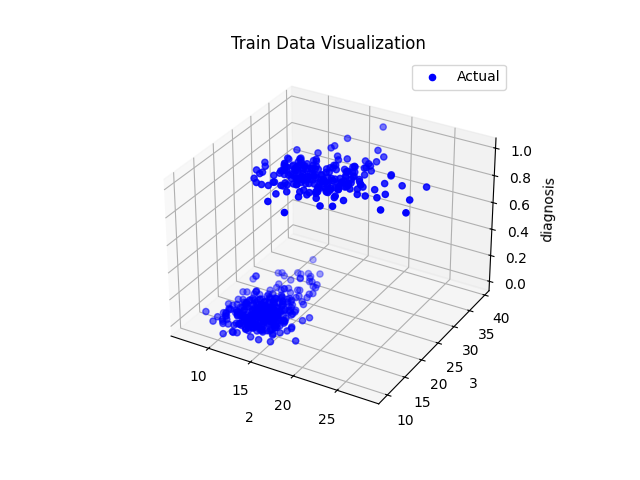

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/wdbc.data', header=None)

# so the columns are not named:
# Diagnosis - 1
# Radius - 2
# Texture - 3

features_names = {'diagnosis': 1, 'radius': 2, 'texture': 3}
target_name = 'diagnosis'

X = df[[features_names['radius'], features_names['texture']]]
Y = df[features_names['diagnosis']].apply(lambda x: 1 if x == 'M' else 0)  # Convert 'M' to 1 and 'B' to 0

%matplotlib widget 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[features_names['radius']], df[features_names['texture']], Y, c='b', marker='o', label='Actual')
ax.set_xlabel(f'{features_names["radius"]}')
ax.set_ylabel(f'{features_names["texture"]}')
ax.set_zlabel(target_name)
ax.set_title('Train Data Visualization')
ax.legend()
plt.show()

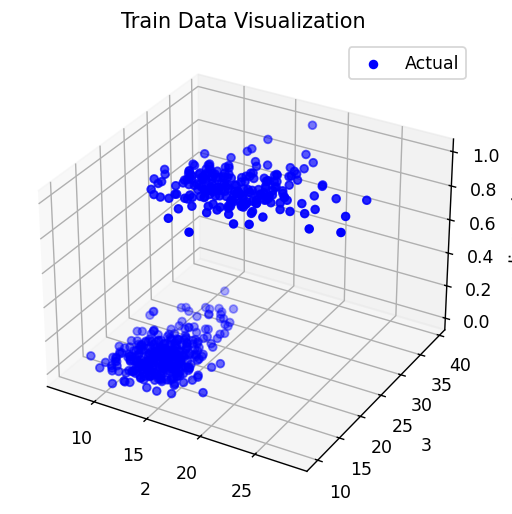

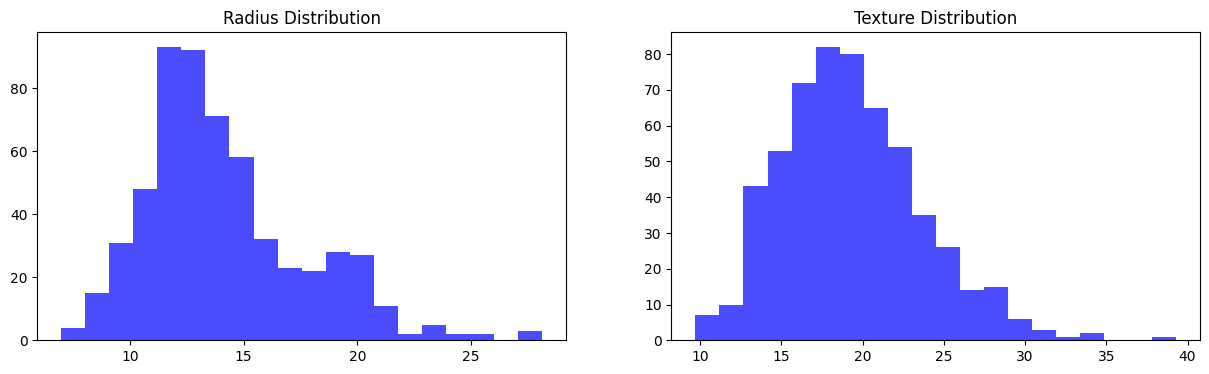

In [ ]:
%matplotlib inline
fig, axes = plt.subplots(1,2, figsize=(15, 4))
for ax, label in zip(axes, ['radius', 'texture']):
	ax.hist(df[features_names[label]], bins=20, color='blue', alpha=0.7)
	ax.set_title(f'{label.capitalize()} Distribution')

We will use _min-max_ normalization to scale the features between 0 and 1. After that we will train our model and evaluate its performance using accuracy score.

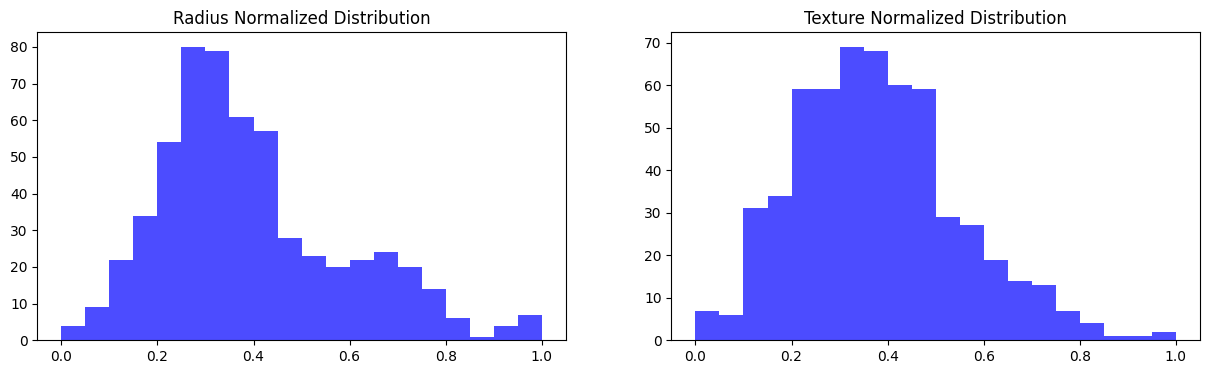

In [104]:
def min_max_normalize(column):
	min_val = column.min()
	max_val = column.max()
	return (column - min_val) / (max_val - min_val)

def clip_outliers(column, top_boundary):
	return [x if x <= top_boundary else top_boundary for x in column]
X[features_names['radius']] = clip_outliers(X[features_names['radius']], 25)
X[features_names['texture']] = clip_outliers(X[features_names['texture']], 35)
X_normalized = X.apply(min_max_normalize)

%matplotlib inline
fig, axes = plt.subplots(1,2, figsize=(15, 4))
for ax, label in zip(axes, ['radius', 'texture']):
	ax.hist(X_normalized[features_names[label]], bins=20, color='blue', alpha=0.7)

	ax.set_title(f'{label.capitalize()} Normalized Distribution')

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, Y_train, Y_test = train_test_split(X_normalized, Y, test_size=0.2, random_state=1)

model = LogisticRegression()
model.fit(X_train, Y_train)
w0 = model.intercept_[0]
w1, w2 = model.coef_[0]
print(f'Learned weights: w0 = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}')
print(f'f(radius, texture) = {w0:.4f} + {w1:.4f} * radius + {w2:.4f} * texture')

accuracy = accuracy_score(Y_test, model.predict(X_test))
print(f'Accuracy on test set: {accuracy * 100:.4f}%')

Learned weights: w0 = -4.8004, w1 = 7.5636, w2 = 2.9538
f(radius, texture) = -4.8004 + 7.5636 * radius + 2.9538 * texture
Accuracy on test set: 83.3333%


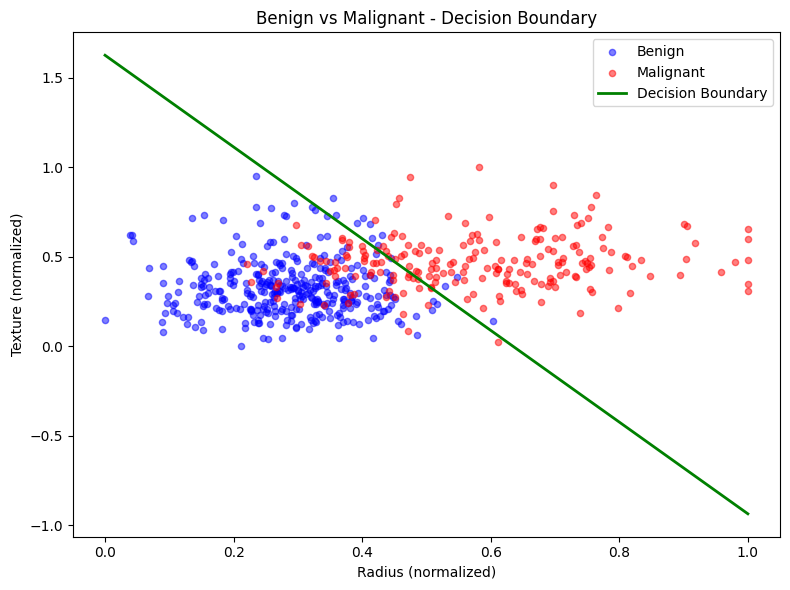

In [106]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in zip([0, 1], ['blue', 'red'], ['Benign', 'Malignant']):
    mask = Y == label
    ax.scatter(X_normalized[mask].iloc[:, 0], X_normalized[mask].iloc[:, 1],
               c=color, marker='o', label=name, alpha=0.5, s=20)

# w0 + w1*x1 + w2*x2 = 0  ->  x2 = -(w0 + w1*x1) / w2
x1_range = np.linspace(X_normalized.iloc[:, 0].min(), X_normalized.iloc[:, 0].max(), 100)
x2_boundary = -(w0 + w1 * x1_range) / w2

ax.plot(x1_range, x2_boundary, 'g-', linewidth=2, label='Decision Boundary')

ax.set_xlabel('Radius (normalized)')
ax.set_ylabel('Texture (normalized)')
ax.set_title('Benign vs Malignant - Decision Boundary')
ax.legend()
plt.tight_layout()
plt.show()

In [107]:
my_prediction = [[18, 10]]
predicted_class = model.predict(my_prediction)[0]
print(f'Predicted class for radius=18 and texture=10: {"Malignant" if predicted_class == 1 else "Benign"}')

Predicted class for radius=18 and texture=10: Malignant


Now that we've seen how logistic regression works. It's time we implement it ourselves. First we will strats with weights that will have a value of 0. Then for every epoch we will calculate the error and update the weights. 
$$ w_i(epoch_t) = w_i(epoch_{t-1}) - \eta \cdot err \cdot x_i $$

Where $err$ is the error calculated as the difference between the predicted value and the actual value. The predicted value is calculated using the sigmoid function as follows:
$$ err = \phi(w_0 + w_1 \cdot radius + w_2 \cdot texture) - y $$

Where $y$ is the actual value (0 for benign and 1 for malignant). We will repeat this process for a number of epochs until we converge to a solution.

In [108]:
import numpy as np

class LogisticRegressionScratch:
	def __init__(self, learning_rate=0.01, epochs=1000, sigmoid_threshold=0.5):
		self.learning_rate = learning_rate
		self.epochs = epochs
		self.sigmoid_threshold = sigmoid_threshold
		self.w0 = 0
		self.w1 = 0
		self.w2 = 0

	def sigmoid(self, z):
		return 1 / (1 + np.exp(-z))

	def fit(self, X, Y):
		for _ in range(self.epochs):
			for i in range(len(X)):
				x1, x2 = X.iloc[i]
				y = Y.iloc[i]
				z = self.w0 + self.w1 * x1 + self.w2 * x2
				y_pred = self.sigmoid(z)
				err = y_pred - y
				self.w0 -= self.learning_rate * err
				self.w1 -= self.learning_rate * err * x1
				self.w2 -= self.learning_rate * err * x2

	def predict(self, X):
		predictions = []
		for i in range(len(X)):
			x1, x2 = X.iloc[i]
			z = self.w0 + self.w1 * x1 + self.w2 * x2
			y_pred = self.sigmoid(z)
			predictions.append(1 if y_pred >= self.sigmoid_threshold else 0)
		return predictions

In [109]:
scared_model = LogisticRegressionScratch(learning_rate=0.01, epochs=1000)
scared_model.fit(X_train, Y_train)

w0 = scared_model.w0
w1 = scared_model.w1
w2 = scared_model.w2
print(f'Learned weights from scratch: w0 = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}')
print(f'f(radius, texture) = {w0:.4f} + {w1:.4f} * radius + {w2:.4f} * texture')

predictions = scared_model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)
print(f'Accuracy of custom logistic regression: {accuracy * 100:.4f}%')

Learned weights from scratch: w0 = -10.4570, w1 = 19.0384, w2 = 5.6521
f(radius, texture) = -10.4570 + 19.0384 * radius + 5.6521 * texture
Accuracy of custom logistic regression: 86.8421%


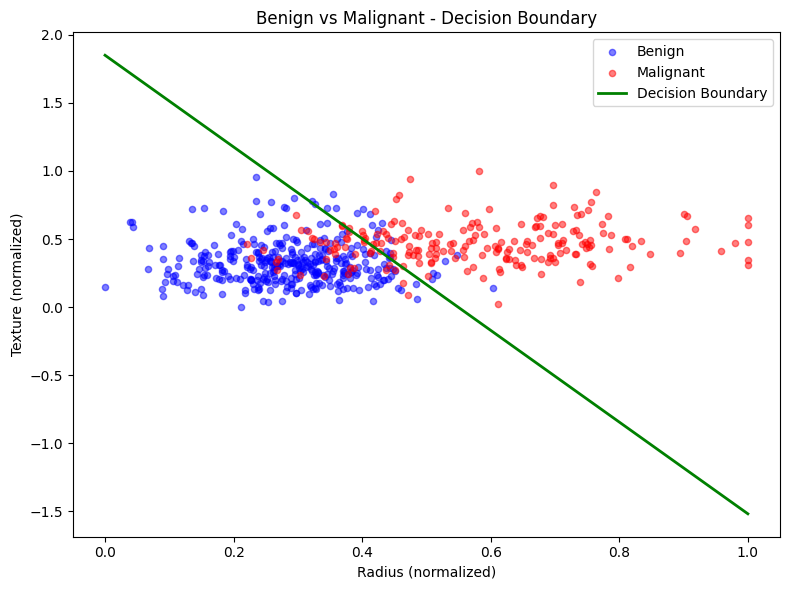

In [110]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in zip([0, 1], ['blue', 'red'], ['Benign', 'Malignant']):
    mask = Y == label
    ax.scatter(X_normalized[mask].iloc[:, 0], X_normalized[mask].iloc[:, 1],
               c=color, marker='o', label=name, alpha=0.5, s=20)

# w0 + w1*x1 + w2*x2 = 0  ->  x2 = -(w0 + w1*x1) / w2
x1_range = np.linspace(X_normalized.iloc[:, 0].min(), X_normalized.iloc[:, 0].max(), 100)
x2_boundary = -(w0 + w1 * x1_range) / w2

ax.plot(x1_range, x2_boundary, 'g-', linewidth=2, label='Decision Boundary')

ax.set_xlabel('Radius (normalized)')
ax.set_ylabel('Texture (normalized)')
ax.set_title('Benign vs Malignant - Decision Boundary')
ax.legend()
plt.tight_layout()
plt.show()

What happends if we change the sigmoid threshold? The default value is 0.5, but we can change it to see how it affects the performance of the model. For example, if we set the threshold to 0.7. This means that we will be more conservative in our predictions and we will only predict that a tissue is malignant if we are very confident about it.

In [111]:
scared_model.sigmoid_threshold = 0.7
predictions = scared_model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)
print(f'Accuracy of custom logistic regression with threshold 0.7: {accuracy * 100:.4f}%')

Accuracy of custom logistic regression with threshold 0.7: 85.9649%


### Multinomial Logistic Regression
Target variable can have 3 or more possible types which are not ordered i.e types have no quantitative significance like “disease A” vs “disease B” vs “disease C”.

In this case, the softmax function is used in place of the sigmoid function. Softmax function for K classes will be:
$$ softmax(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$

Where $z_i$ is the input to the softmax function for class $i$ and the denominator is the sum of the exponentials of the inputs for all classes. The output of the softmax function will be a probability distribution over the K classes, where the probability of each class is between 0 and 1 and the sum of the probabilities for all classes is equal to 1.
$$ P(y=k|x) = \frac{e^{w_k \cdot x}}{\sum_{j=1}^{K} e^{w_j \cdot x}} $$

**All this fancy talk baisicly means** that instead of predicting a single yes/no probability like binary logistic regression, we compute a separate score for each class and then convert all those scores into probabilities that sum to 1. The class with the highest probability wins and becomes the prediction.

For example, if we have 3 diseases A, B, C and our model outputs scores 2.0, 1.0, 0.5 — softmax converts these into something like 0.59, 0.24, 0.17. So the model predicts disease A with 59% confidence.

### Loss Function
For multinomial logistic regression, we use **Cross-Entropy Loss** instead of MSE

### Training
Just like in binary logistic regression, we use Gradient Descent to minimize the loss. The weight update for each class $k$ is:
$$ w_k = w_k - \eta \cdot \frac{\partial J}{\partial w_k} $$

The key difference from binary is that we now have a separate weight vector $w_k$ for **each class**, so the model learns what features are important for distinguishing each class from all the others.

---

### What class of irises does a flower belong to?
We will use the data from [iris database](https://archive.ics.uci.edu/dataset/53/iris) to train a model. In the end we want to predict the class of an iris flower with sepal length of 5.35 and sepal width of 3.85; petal length of 1.25 and petal width of 0.4 cm.

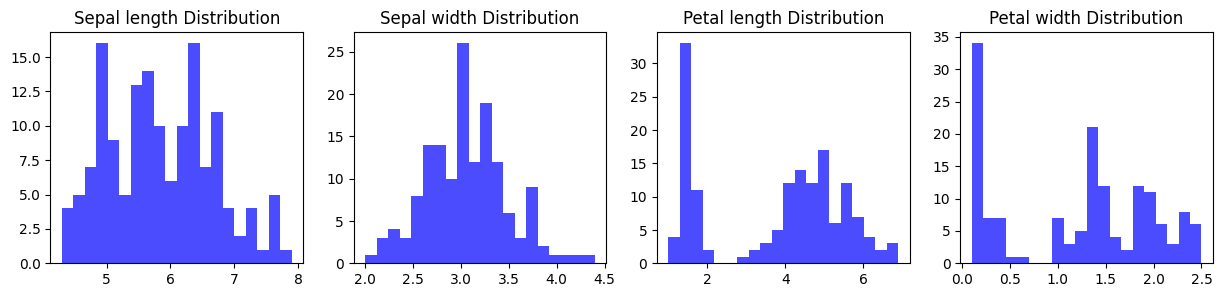

In [112]:
column_names = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']
df = pd.read_csv('data/iris.data', header=None, names=column_names)

%matplotlib inline
fig, axes = plt.subplots(1,4, figsize=(15, 3))
for ax, label in zip(axes, column_names[:-1]):
	ax.hist(df[label], bins=20, color='blue', alpha=0.7)
	ax.set_title(f'{label.capitalize()} Distribution')

In [113]:
X_iris = df[column_names[:-1]]
X_iris_normalized = X_iris.apply(min_max_normalize)

Y = df['class']
X_train, X_test, Y_train, Y_test = train_test_split(X_iris_normalized, Y, test_size=0.2, random_state=1)

model = LogisticRegression()
model.fit(X_train, Y_train)
accuracy = accuracy_score(Y_test, model.predict(X_test))
print(f'Accuracy on iris dataset: {accuracy * 100:.4f}%')

w0 = model.intercept_
w1, w2, w3, w4 = model.coef_[0]
print(f'Learned weights for iris dataset: w0 = {w0[0]:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}, w3 = {w3:.4f}, w4 = {w4:.4f}')
print(f'f(sepal length, sepal width, petal length, petal width) = {w0[0]:.4f} + {w1:.4f} * sepal length + {w2:.4f} * sepal width + {w3:.4f} * petal length + {w4:.4f} * petal width')

my_prediction = pd.DataFrame([[5.35, 3.85, 1.25, 0.4]], columns=column_names[:-1])
predicted_class = model.predict(my_prediction)[0]
print(f'Predicted class for sepal length=5.35, sepal width=3.85, petal length=1.25, petal width=0.4: {predicted_class}')

Accuracy on iris dataset: 90.0000%
Learned weights for iris dataset: w0 = 2.0076, w1 = -1.3189, w2 = 1.3326, w3 = -2.5614, w4 = -2.5240
f(sepal length, sepal width, petal length, petal width) = 2.0076 + -1.3189 * sepal length + 1.3326 * sepal width + -2.5614 * petal length + -2.5240 * petal width
Predicted class for sepal length=5.35, sepal width=3.85, petal length=1.25, petal width=0.4: Iris-virginica


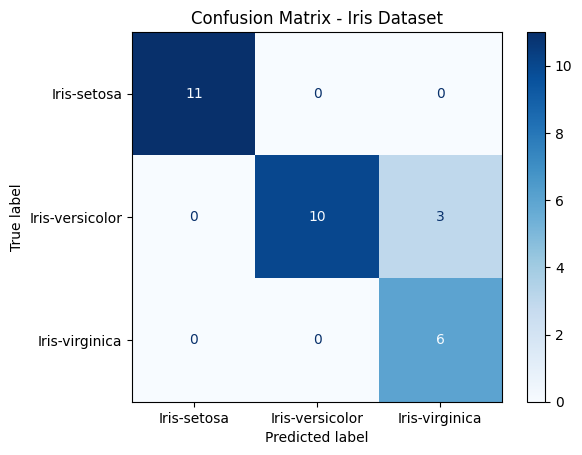

In [114]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(Y_test, model.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix - Iris Dataset')
plt.show()

In [115]:
class LogisticRegressionScratch_Multiclass:
	def __init__(self, learning_rate=0.01, epochs=1000):
		self.learning_rate = learning_rate
		self.epochs = epochs
		self.intercept_ = 0
		self.coef_ = [0] * 4  # Initialize weights for 4 features

	def sigmoid(self, z):
		return 1 / (1 + np.exp(-z))

	def fit(self, X, Y):
		Y = np.array(Y) 
		for _ in range(self.epochs):
			for i in range(len(X)):
				y = Y[i]
				z = self.intercept_ + np.dot(self.coef_, X.iloc[i])

				y_pred = self.sigmoid(z)
				err = y_pred - y
				self.intercept_ -= self.learning_rate * err
				for j, col in enumerate(X.columns):
					self.coef_[j] -= self.learning_rate * err * X.iloc[i][col]

	def predict(self, X):
		scores = []
		for i in range(len(X)):
			z = self.intercept_ + np.dot(self.coef_, X.iloc[i])
			scores.append(z) # row z, no sigmoid here, we will apply softmax later
		return scores

class MulticlassLogisticRegressionScratch:
	def __init__(self, learning_rate=0.01, epochs=1000):
		self.classes = None
		self.learning_rate = learning_rate
		self.epochs = epochs
		self.models_ = {}  # binary logistic regression model for each class

	def softmax(self, z):
		exp_z = np.exp(z - np.max(z))
		return exp_z / exp_z.sum()

	def fit(self, X, Y):
		self.classes = list(np.unique(Y))
		n_classes = len(self.classes)

		Y_encoded = pd.Series([self.classes.index(y) for y in Y])

		for cls in range(n_classes):
			model = LogisticRegressionScratch_Multiclass(learning_rate=self.learning_rate, epochs=self.epochs)
			model.fit(X, pd.Series([1 if label == cls else 0 for label in Y_encoded]))
			self.models_[cls] = model

	def predict(self, X):
		predictions = []
		for i in range(len(X)):
			# get raw score from each binary model
			scores = [self.models_[cls].predict(X.iloc[[i]])[0] for cls in self.models_]
			# softmax over scores, pick the class with highest probability
			probs = self.softmax(np.array(scores))
			predictions.append(self.classes[np.argmax(probs)])
		return predictions

In [116]:
model_scratch_multiclass = MulticlassLogisticRegressionScratch(learning_rate=0.01, epochs=1000)
model_scratch_multiclass.fit(X_train, Y_train)
predictions = model_scratch_multiclass.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)
print(f'Accuracy of custom multiclass logistic regression: {accuracy * 100:.4f}%')
print(predictions)

Accuracy of custom multiclass logistic regression: 83.3333%
['Iris-setosa', 'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


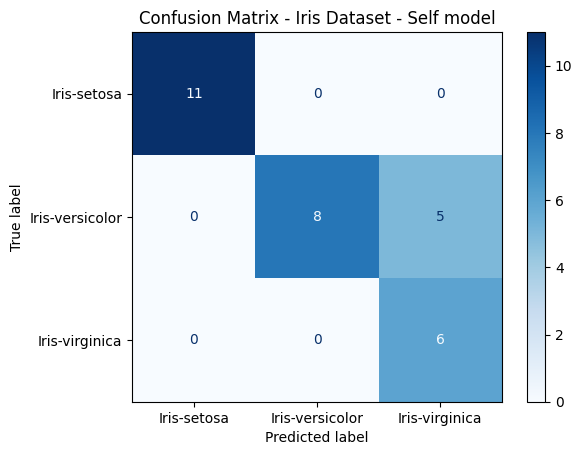

In [117]:
cm = confusion_matrix(Y_test, predictions)
ConfusionMatrixDisplay(cm, display_labels=model_scratch_multiclass.classes).plot(cmap='Blues')
plt.title('Confusion Matrix - Iris Dataset - Self model')
plt.show()

In [118]:
predicted_class_scrach = model_scratch_multiclass.predict(my_prediction)
print(f'Predicted class: {predicted_class_scrach[0]}')

Predicted class: Iris-setosa


Sooooo... yeah, we got diffrent answers form the two models. The one we implemented from scratch predicted that the flower belongs to the class "Iris-setosa" while the one from sklearn predicted that it belongs to the class "Iris-versicolor". This is because our model is not trained well enough and it needs more epochs to converge to a "better" solution.

### Diffrent Loss Functions
In logistic regression, we can use diffrent loss functions to train our model. The most common loss function is the **cross-entropy loss** which we have already seen. Another loss function that we can use is the **hinge loss** which is used in Support Vector Machines (SVMs). The hinge loss is defined as:
$$ J(w) = \sum_{i=1}^{n} \max(0, 1 - y_i \cdot (w \cdot x_i)) $$

The hinge loss penalizes the model when it makes a wrong prediction and it encourages the model to make a correct prediction with a margin of at least 1.

In [119]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

model_crossentropy = SGDClassifier(loss='log_loss')   # cross-entropy
model_hinge = SGDClassifier(loss='hinge')             # SVM-style loss

scores_ce = cross_val_score(model_crossentropy, X_iris_normalized, Y, cv=5)

print("Cross-Validation Results (Accuracy) with Cross Entropy:")
for i, result in enumerate(scores_ce, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")
    
print(f'Mean Accuracy: {scores_ce.mean()* 100:.2f}%')

scores_hinge = cross_val_score(model_hinge, X_iris_normalized, Y, cv=5)

print("Cross-Validation Results (Accuracy) with Hinge:")
for i, result in enumerate(scores_hinge, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")
    
print(f'Mean Accuracy: {scores_hinge.mean()* 100:.2f}%')

Cross-Validation Results (Accuracy) with Cross Entropy:
  Fold 1: 83.33%
  Fold 2: 86.67%
  Fold 3: 90.00%
  Fold 4: 93.33%
  Fold 5: 86.67%
Mean Accuracy: 88.00%
Cross-Validation Results (Accuracy) with Hinge:
  Fold 1: 86.67%
  Fold 2: 90.00%
  Fold 3: 93.33%
  Fold 4: 86.67%
  Fold 5: 83.33%
Mean Accuracy: 88.00%


What can we deduce from the result?

Well, the model trained with cross-entropy loss performed better, cuz' he be the GOAT. 